In [21]:
import requests
import pandas as pd

from config import APP_ID, APP_KEY

search_terms = [
    "data scientist",
    "machine learning engineer",
    "ai engineer",
    "data analyst",
    "software engineer",
    "data engineer",
    "business analyst"
]

all_jobs = []

for term in search_terms:

    url = (
        f"https://api.adzuna.com/v1/api/jobs/au/search/1"
        f"?app_id={APP_ID}"
        f"&app_key={APP_KEY}"
        f"&results_per_page=50"
        f"&what={term}"
    )

    response = requests.get(url)

    print(f"{term}: Status Code {response.status_code}")

    data = response.json()

    for job in data["results"]:
        all_jobs.append({
            "search_term": term,
            "title": job.get("title"),
            "company": job.get("company", {}).get("display_name"),
            "location": job.get("location", {}).get("display_name"),
            "salary_min": job.get("salary_min"),
            "salary_max": job.get("salary_max"),
            "description": job.get("description"),
            "created": job.get("created")
        })

print(f"\nTotal jobs collected: {len(all_jobs)}")

data scientist: Status Code 200
machine learning engineer: Status Code 200
ai engineer: Status Code 200
data analyst: Status Code 200
software engineer: Status Code 200
data engineer: Status Code 200
business analyst: Status Code 200

Total jobs collected: 350


In [22]:
df = pd.DataFrame(all_jobs)

print(f"Rows: {len(df)}")

df.head()

Rows: 350


,search_term,title,company,location,salary_min,salary_max,description,created
0,data scientist,Data Scientist,GRIT Talent Consulting,"Brisbane, Brisbane Region",140000.0,140000.0,"We are seeking a Data Scientist for a hybrid, ...",2026-06-10T07:40:07Z
1,data scientist,Data Scientist,Jivaro,"Melbourne, Melbourne Region",150000.0,150000.0,One of Australia’s most recognised retail busi...,2026-05-28T07:22:00Z
2,data scientist,Data Scientist,Mane Consulting,"Sydney, Sydney Region",150000.0,175000.0,Get recognition and reward working with this a...,2026-06-03T11:18:11Z
3,data scientist,Data Scientist,HorizonOne,"Canberra Region, Australian Capital Territory",208000.0,291200.0,This role is within a large federal social pol...,2026-05-26T07:35:37Z
4,data scientist,Data Scientist,SKL Actuarial,"The Rocks, Sydney",NaN,NaN,Permanent roles within a dynamic insurance bus...,2026-06-17T08:53:44Z


In [23]:
df = df.drop_duplicates(
    subset=["title", "company"],
    keep="first"
)

print(f"Rows after removing duplicates: {len(df)}")

Rows after removing duplicates: 280


In [24]:
df.to_csv("data/raw/jobs.csv", index=False)

print("File saved")

File saved


In [25]:
import os

print(os.listdir("data/raw"))

['.ipynb_checkpoints', 'jobs.csv']


In [26]:
print(f"Total jobs: {len(df)}")
print(f"Unique companies: {df['company'].nunique()}")
print(f"Unique locations: {df['location'].nunique()}")

df.head()

Total jobs: 280
Unique companies: 226
Unique locations: 59


,search_term,title,company,location,salary_min,salary_max,description,created
0,data scientist,Data Scientist,GRIT Talent Consulting,"Brisbane, Brisbane Region",140000.0,140000.0,"We are seeking a Data Scientist for a hybrid, ...",2026-06-10T07:40:07Z
1,data scientist,Data Scientist,Jivaro,"Melbourne, Melbourne Region",150000.0,150000.0,One of Australia’s most recognised retail busi...,2026-05-28T07:22:00Z
2,data scientist,Data Scientist,Mane Consulting,"Sydney, Sydney Region",150000.0,175000.0,Get recognition and reward working with this a...,2026-06-03T11:18:11Z
3,data scientist,Data Scientist,HorizonOne,"Canberra Region, Australian Capital Territory",208000.0,291200.0,This role is within a large federal social pol...,2026-05-26T07:35:37Z
4,data scientist,Data Scientist,SKL Actuarial,"The Rocks, Sydney",NaN,NaN,Permanent roles within a dynamic insurance bus...,2026-06-17T08:53:44Z


In [27]:
top_roles = df["title"].value_counts()

top_roles.head(20)

title
Software Engineer                                              38
Data Engineer                                                  37
Business Analyst                                               36
Data Analyst                                                   32
Data Scientist                                                 18
Senior Data Scientist                                          18
AI Engineer                                                    15
Senior AI Engineer                                              7
Machine Learning Engineer                                       5
Senior Data Analyst                                             4
Principal Data Scientist                                        2
Senior Machine Learning Engineer                                2
Lead Machine Learning Engineer                                  2
Principal AI Engineer                                           2
AI Engineer Intern                                              2
Lead

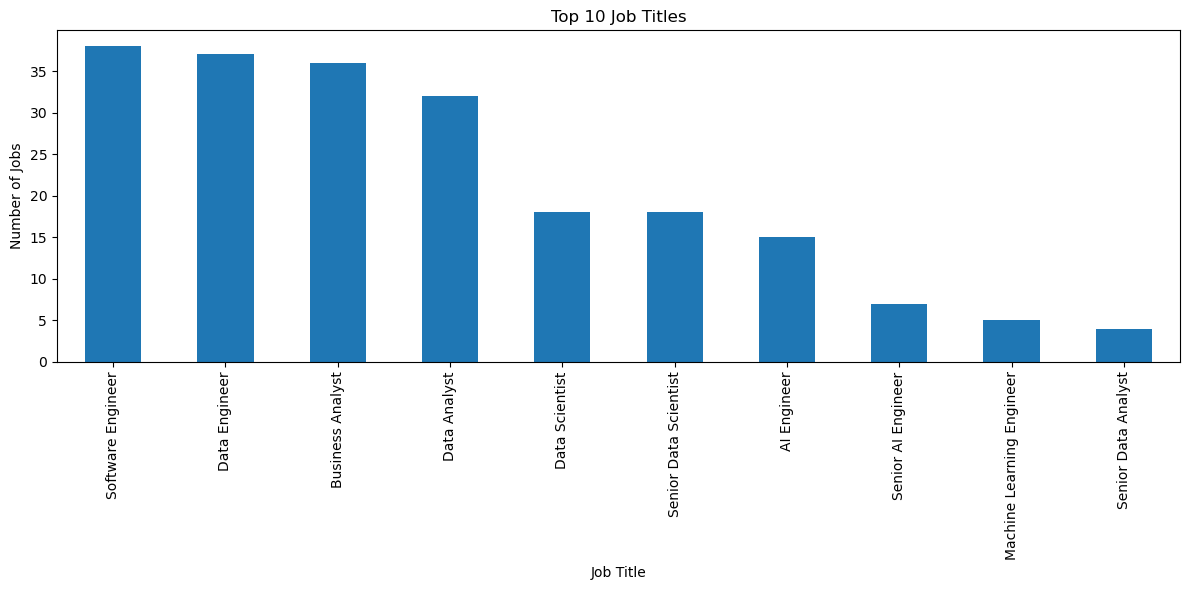

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df["title"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Job Titles")
plt.ylabel("Number of Jobs")
plt.xlabel("Job Title")

plt.tight_layout()
plt.show()

In [69]:
def extract_city(location):
    if pd.isna(location):
        return "Other"

    location = location.lower()

        # Remote / Australia-wide
    if "australia" in location:
        return "Remote Australia"

    # Melbourne
    if any(word in location for word in [
        "melbourne",
        "yarra",
        "stonnington",
        "monash",
        "port phillip",
        "moonee valley",
        "wyndham",
        "cardinia"
    ]):
        return "Melbourne"

    # Sydney
    if any(word in location for word in [
        "sydney",
        "rockdale",
        "canada bay",
        "ashfield",
        "botany",
        "auburn",
        "gosford"
        "Denistone West"
    ]):
        return "Sydney"

    # Brisbane
    if any(word in location for word in [
        "brisbane",
        "pine rivers",
        "gold coast"
    ]):
        return "Brisbane"

    # Perth
    if any(word in location for word in [
        "perth",
        "rockingham"
        "Osborne Park"
        "Bayswater"
    ]):
        return "Perth"

    # Adelaide
    if any(word in location for word in [
        "adelaide",
        "charles sturt"
    ]):
        return "Adelaide"
        
    # Canberra
    if any(word in location for word in [
        "canberra",
        "barton"
    ]):
        return "Canberra"
        
    # Darwin
    if "darwin" in location:
        return "Darwin"

    return "Other"


df["city"] = df["location"].apply(extract_city)

df[["location", "city"]].head(10)

,location,city
0,"Brisbane, Brisbane Region",Brisbane
1,"Melbourne, Melbourne Region",Melbourne
2,"Sydney, Sydney Region",Sydney
3,"Canberra Region, Australian Capital Territory",Remote Australia
4,"The Rocks, Sydney",Sydney
5,"Bayswater, Bayswater Area",Other
6,"Brisbane CBD, Brisbane",Brisbane
7,"Adelaide CBD, Adelaide",Adelaide
8,"Banksia, Rockdale Area",Sydney
9,"Victoria, Australia",Remote Australia


In [70]:
top_locations = df["city"].value_counts()

top_locations

city
Sydney              92
Melbourne           56
Remote Australia    38
Brisbane            23
Canberra            23
Other               18
Adelaide            18
Perth                8
Darwin               4
Name: count, dtype: int64

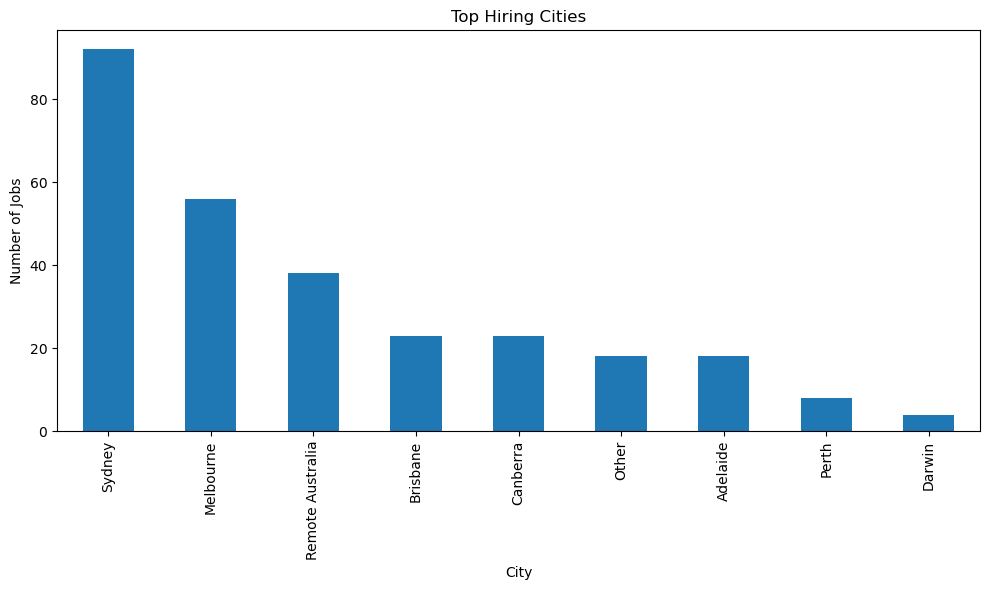

In [71]:
plt.figure(figsize=(10,6))

df["city"].value_counts().plot(kind="bar")

plt.title("Top Hiring Cities")
plt.ylabel("Number of Jobs")
plt.xlabel("City")

plt.tight_layout()
plt.show()

In [72]:
df["title"].value_counts().head(20)

title
Software Engineer                                              38
Data Engineer                                                  37
Business Analyst                                               36
Data Analyst                                                   32
Data Scientist                                                 18
Senior Data Scientist                                          18
AI Engineer                                                    15
Senior AI Engineer                                              7
Machine Learning Engineer                                       5
Senior Data Analyst                                             4
Principal Data Scientist                                        2
Senior Machine Learning Engineer                                2
Lead Machine Learning Engineer                                  2
Principal AI Engineer                                           2
AI Engineer Intern                                              2
Lead

In [73]:
df[df["city"] == "Other"]["location"].value_counts().head(30)

location
Bayswater, Bayswater Area        5
Emu Flat, Clare Area             1
Somersby, Gosford Area           1
Gosford, Gosford Area            1
Rockingham, Rockingham Area      1
Erakala, Mackay                  1
Rock Flat, Cooma-Monaro Area     1
North Ward, Townsville           1
Denistone West, Ryde Area        1
Osborne Park, Stirling Area      1
Keilor Lodge, Brimbank Area      1
Wimbledon Heights, Bass Coast    1
Tullamarine, Hume Area           1
Hobart, Hobart Region            1
Name: count, dtype: int64

In [76]:
# Machine Learning: Job Clustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

df["text"] = (
    df["title"].fillna("") + " " +
    df["description"].fillna("")
)

df[["title", "text"]].head()

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X = vectorizer.fit_transform(df["text"])

In [90]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X = vectorizer.fit_transform(df["text"])

In [92]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df["cluster"] = kmeans.fit_predict(X)

cluster_names = {
    0: "AI / Machine Learning Engineering",
    1: "Software Engineering & Data Platforms",
    2: "Data Science, Analytics & Engineering",
    3: "Industry & Specialist Analytics",
    4: "Business Analytics"
}

df["cluster_name"] = df["cluster"].map(cluster_names)
#this will show a lot of Data scientist which is normal because it is the first search term and thus goes first.
df[["title", "cluster", "cluster_name"]].head(20)

,title,cluster,cluster_name
0,Data Scientist,2,"Data Science, Analytics & Engineering"
1,Data Scientist,2,"Data Science, Analytics & Engineering"
2,Data Scientist,2,"Data Science, Analytics & Engineering"
3,Data Scientist,2,"Data Science, Analytics & Engineering"
4,Data Scientist,2,"Data Science, Analytics & Engineering"
5,Data Scientist,2,"Data Science, Analytics & Engineering"
6,Data Scientist,2,"Data Science, Analytics & Engineering"
7,Data Scientist,1,Software Engineering & Data Platforms
8,Data Scientist,2,"Data Science, Analytics & Engineering"
9,Data Scientist,2,"Data Science, Analytics & Engineering"


In [93]:
for cluster in sorted(df["cluster"].unique()):

    print("\nCluster:", cluster)
    print("Category:", cluster_names[cluster])
    print("-"*40)

    print(
        df[df["cluster"] == cluster]["title"]
        .value_counts()
        .head(10)
    )


Cluster: 0
Category: AI / Machine Learning Engineering
----------------------------------------
title
AI Engineer                         11
Senior AI Engineer                   6
Machine Learning Engineer            5
Senior Machine Learning Engineer     2
AI Engineer Intern                   2
Lead AI Engineer                     2
Generative AI Engineer               2
Applied AI Engineer                  2
Software Engineer                    2
Senior Data Scientist                1
Name: count, dtype: int64

Cluster: 1
Category: Software Engineering & Data Platforms
----------------------------------------
title
Software Engineer                                                 31
Data Engineer                                                     11
Data Analyst                                                       9
Data Scientist                                                     3
AI Engineer                                                        3
Senior Data Scientist        

In [94]:
terms = vectorizer.get_feature_names_out()

for cluster in range(5):

    center = kmeans.cluster_centers_[cluster]

    top_terms = center.argsort()[-10:][::-1]

    print("\nCluster:", cluster)
    print("Category:", cluster_names[cluster])
    print("Key terms:")

    print([terms[i] for i in top_terms])
    


Cluster: 0
Category: AI / Machine Learning Engineering
Key terms:
['ai', 'engineer', 'learning', 'machine', 'engineering', 'design', 'll', 'senior', 'role', 'team']

Cluster: 1
Category: Software Engineering & Data Platforms
Key terms:
['software', 'engineer', 'australia', 'technology', 'company', 'data', 'team', 'people', 'role', 'based']

Cluster: 2
Category: Data Science, Analytics & Engineering
Key terms:
['data', 'scientist', 'analyst', 'role', 'analytics', 'senior', 'engineer', 'reporting', 'making', 'business']

Cluster: 3
Category: Industry & Specialist Analytics
Key terms:
['business', 'data', 'analyst', 'operations', 'plenti', 'role', 'position', 'energy', 'australia', 'learning']

Cluster: 4
Category: Business Analytics
Key terms:
['business', 'analyst', 'role', 'delivery', 'support', 'requirements', 'stakeholders', 'initiatives', 'contract', 'transformation']
